# CoDec Spotlight Dataset Comparison

Compares the four CoDec strategy configs defined in
[`compare_ucr.py`](compare_ucr.py) across the five "characteristic spotlight"
datasets named in `CoDec_workplan.md` §0 and `CoDec_presentation.pdf`'s
Experimental Plan slide:

| Dataset | Characteristic |
|---|---|
| CBF | shape-driven, low frequency reliance |
| ECG5000 | morphology-critical |
| FordA | frequency-heavy, noisy |
| Yoga | subtle amplitude / shape |
| TwoPatterns | synthetic, controlled |

| Config | Decomposition | Reference selection | Matching |
|---|---|---|---|
| `imfact_baseline` | EMD | NUN | Index |
| `hungarian_matching` | EMD | NUN | Hungarian |
| `composite_reference` | EMD | Composite (favored) | Hungarian |
| `fourier_decomposition` | Fourier | Composite | Hungarian |

This notebook reads the already-computed `results.csv` / `summary.csv` files
under `experiments/results/<dataset>_codec_ablation/` (produced by running
`python compare_ucr.py --dataset <name>` for each dataset with its default
settings: 30 correctly-classified test samples, `k=5`, `max_iter=25`) rather
than re-running the search. Re-run `compare_ucr.py` first if you want fresh
numbers or different settings.

In [1]:
from __future__ import annotations

import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "cfts").exists():
        REPO_ROOT = candidate
        break
else:
    raise RuntimeError("Could not locate repository root containing cfts/")

RESULTS_DIR = REPO_ROOT / "cfts" / "cf_codec" / "experiments" / "results"

DATASETS = ["CBF", "ECG5000", "FordA", "Yoga", "TwoPatterns"]
CONFIG_ORDER = ["imfact_baseline", "hungarian_matching", "composite_reference", "fourier_decomposition"]
CONFIG_COLORS = {
    "imfact_baseline": "#8d99ae",
    "hungarian_matching": "#457b9d",
    "composite_reference": "#e63946",
    "fourier_decomposition": "#2a9d8f",
}

plt.style.use("seaborn-v0_8-darkgrid")
plt.rcParams.update({"font.size": 12})

print(f"Repo root:   {REPO_ROOT}")
print(f"Results dir: {RESULTS_DIR}")

Repo root:   /workspaces/counterfactual-explanations-for-time-series
Results dir: /workspaces/counterfactual-explanations-for-time-series/cfts/cf_codec/experiments/results


## Load results

One `summary.csv` (dataset x config aggregates) and one `results.csv` (per-sample records) per spotlight dataset, produced by `compare_ucr.py`.

In [2]:
summaries, per_sample = [], []
for ds in DATASETS:
    d = RESULTS_DIR / f"{ds.lower()}_codec_ablation"
    if not d.exists():
        raise FileNotFoundError(
            f"No results for {ds} at {d}. Run:\n"
            f"  python compare_ucr.py --dataset {ds}\nfirst."
        )
    summary = pd.read_csv(d / "summary.csv")
    summary.insert(0, "dataset", ds)
    summaries.append(summary)

    results = pd.read_csv(d / "results.csv")
    results.insert(0, "dataset", ds)
    per_sample.append(results)

summary_df = pd.concat(summaries, ignore_index=True)
summary_df["config"] = pd.Categorical(summary_df["config"], categories=CONFIG_ORDER, ordered=True)
summary_df["dataset"] = pd.Categorical(summary_df["dataset"], categories=DATASETS, ordered=True)
summary_df = summary_df.sort_values(["dataset", "config"]).reset_index(drop=True)

results_df = pd.concat(per_sample, ignore_index=True)

print(f"Loaded {len(summary_df)} dataset x config summaries, {len(results_df)} per-sample records.")
summary_df[["dataset", "config", "n_total", "validity_rate", "l2_norm_mean",
            "n_components_changed_mean", "elapsed_mean", "n_errors"]]

Loaded 20 dataset x config summaries, 600 per-sample records.


,dataset,config,n_total,validity_rate,l2_norm_mean,n_components_changed_mean,elapsed_mean,n_errors
0,CBF,imfact_baseline,30,0.966667,9.101184,3.633333,0.012022,0
1,CBF,hungarian_matching,30,1.000000,8.181992,2.500000,0.008081,0
2,CBF,composite_reference,30,0.766667,9.328372,3.166667,0.014941,0
3,CBF,fourier_decomposition,30,0.666667,11.436207,2.266667,0.008401,0
4,ECG5000,imfact_baseline,30,0.700000,8.779038,3.766667,0.015551,0
5,ECG5000,hungarian_matching,30,0.733333,8.340910,3.433333,0.015918,0
6,ECG5000,composite_reference,30,0.366667,7.895619,3.400000,0.014840,0
7,ECG5000,fourier_decomposition,30,0.533333,11.582457,2.866667,0.008332,0
8,FordA,imfact_baseline,30,1.000000,22.232510,4.633333,0.011701,0
9,FordA,hungarian_matching,30,1.000000,23.693429,3.300000,0.011683,0


## Classifier quality per dataset

Counterfactual quality is only as trustworthy as the classifier CoDec is explaining - pulled from `spotlight_run.log` (`SimpleCNN`, 30 training epochs) for context.

In [3]:
log_path = RESULTS_DIR / "spotlight_run.log"
f1_scores = {}
if log_path.exists():
    text = log_path.read_text()
    blocks = re.split(r"=== START (\w+)", text)[1:]
    for name, block in zip(blocks[0::2], blocks[1::2]):
        m = re.search(r"Macro F1: ([\d.]+)", block)
        if m:
            f1_scores[name] = float(m.group(1))

f1_df = pd.DataFrame({"dataset": DATASETS, "classifier_macro_f1": [f1_scores.get(ds) for ds in DATASETS]})
f1_df

,dataset,classifier_macro_f1
0,CBF,0.9085
1,ECG5000,0.4769
2,FordA,0.9242
3,Yoga,0.7903
4,TwoPatterns,0.9998


## Validity / proximity / sparsity / time, grouped by config

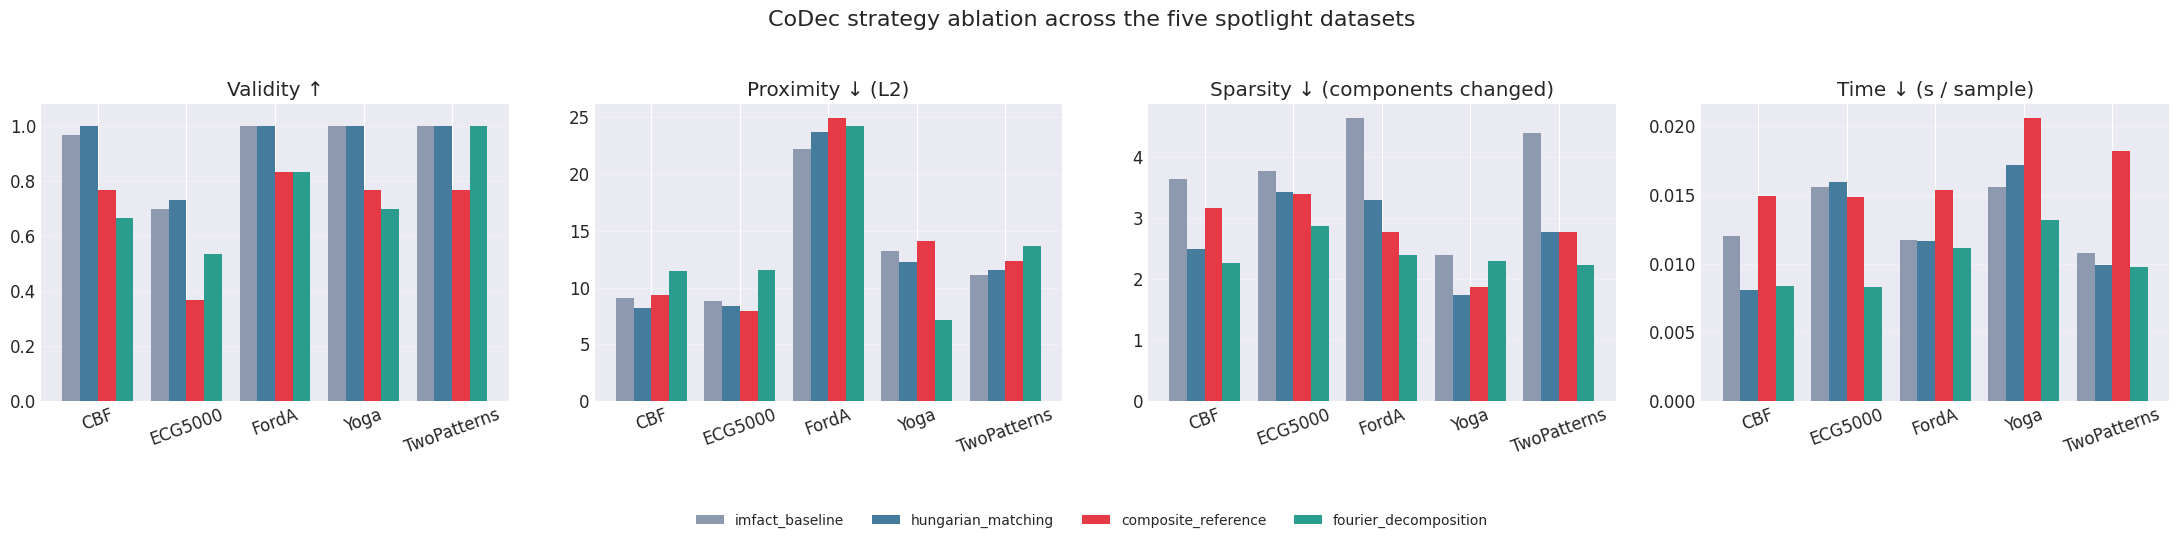

In [4]:
metrics_panels = [
    ("validity_rate", "Validity ↑", (0, 1.08)),
    ("l2_norm_mean", "Proximity ↓ (L2)", None),
    ("n_components_changed_mean", "Sparsity ↓ (components changed)", None),
    ("elapsed_mean", "Time ↓ (s / sample)", None),
]

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
x = np.arange(len(DATASETS))
width = 0.2

for ax, (col, title, ylim) in zip(axes, metrics_panels):
    for i, cfg in enumerate(CONFIG_ORDER):
        vals = [
            summary_df[(summary_df.dataset == ds) & (summary_df.config == cfg)][col].iloc[0]
            for ds in DATASETS
        ]
        ax.bar(x + (i - 1.5) * width, vals, width=width, label=cfg, color=CONFIG_COLORS[cfg])
    ax.set_xticks(x)
    ax.set_xticklabels(DATASETS, rotation=20)
    ax.set_title(title)
    if ylim:
        ax.set_ylim(*ylim)
    ax.grid(True, axis="y", alpha=0.3)

fig.suptitle("CoDec strategy ablation across the five spotlight datasets", fontsize=16)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, -0.08), ncol=4, fontsize=10)
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

## Validity heatmap

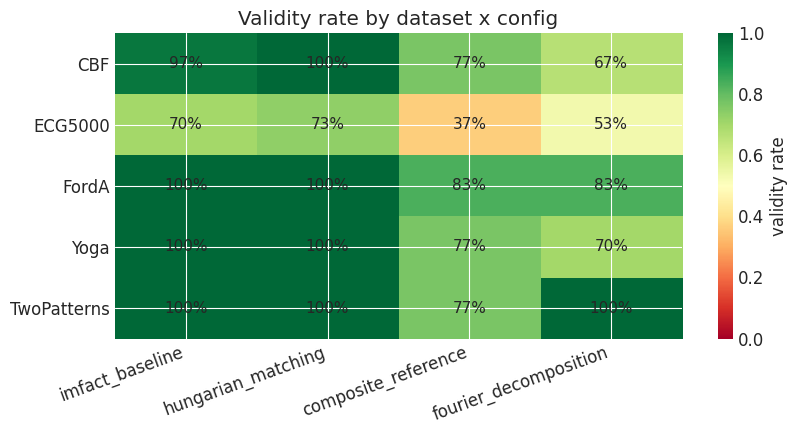

In [5]:
pivot = summary_df.pivot(index="dataset", columns="config", values="validity_rate").loc[DATASETS, CONFIG_ORDER]

fig, ax = plt.subplots(figsize=(8.5, 4.5))
im = ax.imshow(pivot.values, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(CONFIG_ORDER)))
ax.set_xticklabels(CONFIG_ORDER, rotation=20, ha="right")
ax.set_yticks(range(len(DATASETS)))
ax.set_yticklabels(DATASETS)
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        ax.text(j, i, f"{pivot.values[i, j]:.0%}", ha="center", va="center", fontsize=11)
ax.set_title("Validity rate by dataset x config")
fig.colorbar(im, ax=ax, label="validity rate")
plt.tight_layout()
plt.show()

## Isolating each design choice

- **Matching** (index vs. Hungarian, both EMD + NUN): `hungarian_matching - imfact_baseline`
- **Reference selection** (NUN vs. composite, both EMD + Hungarian): `composite_reference - hungarian_matching`
- **Decomposition** (EMD vs. Fourier, both composite + Hungarian): `fourier_decomposition - composite_reference`

In [6]:
deltas = pd.DataFrame({
    "matching (Hungarian - Index)": pivot["hungarian_matching"] - pivot["imfact_baseline"],
    "reference (Composite - NUN)": pivot["composite_reference"] - pivot["hungarian_matching"],
    "decomposition (Fourier - EMD)": pivot["fourier_decomposition"] - pivot["composite_reference"],
})
deltas.style.format("{:+.1%}").background_gradient(cmap="RdYlGn", vmin=-0.5, vmax=0.5, axis=None)

,matching (Hungarian - Index),reference (Composite - NUN),decomposition (Fourier - EMD)
dataset,,,
CBF,+3.3%,-23.3%,-10.0%
ECG5000,+3.3%,-36.7%,+16.7%
FordA,+0.0%,-16.7%,+0.0%
Yoga,+0.0%,-23.3%,-6.7%
TwoPatterns,+0.0%,-23.3%,+23.3%


## Validity vs. sparsity cost trade-off

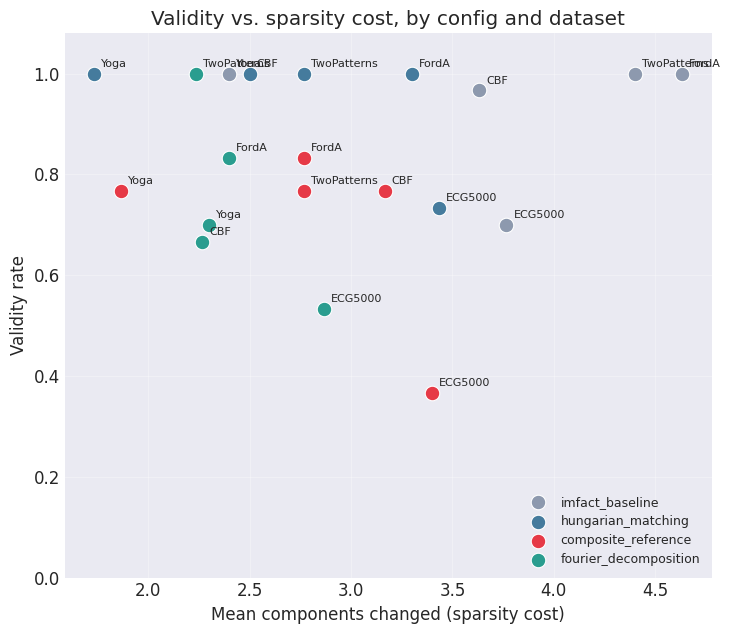

In [7]:
fig, ax = plt.subplots(figsize=(7.5, 6.5))
for cfg in CONFIG_ORDER:
    sub = summary_df[summary_df.config == cfg]
    ax.scatter(sub["n_components_changed_mean"], sub["validity_rate"], s=110,
               color=CONFIG_COLORS[cfg], label=cfg, edgecolor="white", linewidth=0.8, zorder=3)
    for _, row in sub.iterrows():
        ax.annotate(row["dataset"], (row["n_components_changed_mean"], row["validity_rate"]),
                    fontsize=8, xytext=(5, 5), textcoords="offset points")

ax.set_xlabel("Mean components changed (sparsity cost)")
ax.set_ylabel("Validity rate")
ax.set_title("Validity vs. sparsity cost, by config and dataset")
ax.set_ylim(0, 1.08)
ax.legend(loc="lower right", fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Takeaways

- **Hungarian matching is a consistent win.** `hungarian_matching` matches or beats
  `imfact_baseline` on validity in every dataset while changing noticeably fewer
  components - direct support for the workplan's #1 priority item.
- **`composite_reference` - the presentation's favored strategy - has the *lowest*
  validity of the four configs on every single dataset.** This is the opposite of
  what slide 8 predicts, and is worth investigating rather than taking at face
  value: unlike the NUN-based configs, composite selection commits to one
  pool-stitched component ordering with nowhere else to fall back to if that
  ordering doesn't flip the class within `max_iter` - it can't "try the next
  reference" the way single-NUN search can. A composite variant that can also
  retry with an alternate pool subset would be a natural next experiment before
  concluding the strategy itself is weaker.
- **Decomposition choice (EMD vs. Fourier) is dataset-dependent.** Fourier bands
  underperform EMD on most spotlight sets (consistent with the workplan's
  heuristic table favoring EMD for shape/morphology-driven series) but match or
  beat it on TwoPatterns ("synthetic, controlled"), where clean frequency
  separation plausibly favors a hard STFT-band split.

**Caveats:** `n=30` samples per dataset, one seed, untuned `k` / `max_iter` /
`pool_k` - this is an exploratory pass, not a paper-ready benchmark. ECG5000's
numbers in particular should be read alongside its classifier's low macro F1
(imbalanced 5-class dataset).